# sub1データのアノテーター間比較

In [1]:
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import json

In [2]:
with open('../data/sub1_recipe_10.json', 'r') as f:
    recipe = json.load(f)

recipe

[{'title': '例題1：トマトの冷やしおでん風',
  'ingredients': ['トマト 4コ（300g）',
   '油揚げ 40g',
   '【A】 だし カップ1+1/2',
   '【A】 うす口しょうゆ 大さじ1',
   'すだち（薄い輪切り） 適量',
   '七味とうがらし 適宜'],
  'instructions': ['1. トマトはヘタをくりぬく。油揚げは1.5cm幅の短冊形に切る。',
   '2. 小鍋に【A】を入れて中火にかけ、煮立ったら1のトマトを加える。皮がはじけたら取り出し、皮をむいて耐熱の保存容器に入れる。',
   '3. 2の小鍋に1の油揚げを加え、しんなりとするまで1分間ほど煮る。煮汁ごと2の保存容器に注ぎ入れ、そのまま冷ます。',
   '4. 器に盛ってすだちを添え、あれば七味とうがらしをふる。']},
 {'title': '例題2：ジャンボプリン',
  'ingredients': ['【カラメルソース】 グラニュー糖 80g',
   '【カラメルソース】 水 小さじ1',
   '卵 3コ',
   '卵黄 3コ分',
   'グラニュー糖 120g',
   '牛乳 カップ4',
   '生クリーム カップ1/2'],
  'instructions': ['1. 【カラメルソース】をつくる。小鍋にグラニュー糖を入れて分量の水を鍋の縁から加え、混ぜずに弱火にかける。グラニュー糖が溶けはじめたら、鍋を揺すって焦げつかないようにし、液状になって色づくまで5～10分間加熱する。泡が落ち着いて焦げ茶色になる一歩手前で火から下ろす。型に注ぎ入れ、底面全体に広げる。',
   '2. ボウルに卵と卵黄を入れてよく溶きほぐし、グラニュー糖を加えて泡立てないようによく混ぜる。',
   '3. 鍋に牛乳と生クリームを合わせて中火にかける。時々混ぜながらしっかり沸騰させ、そのまま20秒間火にかけ、ふきこぼれる直前で火を止める。',
   '4. 2に3の1/4量を加え、泡立て器でよく混ぜる。残りの3を一気に加え、ゴムべらに持ちかえてしっかり混ぜ合わせる。',
   '5. 1の型に4をこしながら流し入れ、表面の泡をスプーンの背でつぶす。天板にのせてオーブンに入れたら、天板の高さギリギリまで熱湯を静かに注ぎ入

In [3]:
PATH = "../outputs/"
ANNOTATORS = ["A", "B", "C", "ad"]

raw_data = {}
for ann in ANNOTATORS:
    with open(PATH + f"{ann}_sub1_annotated.json", encoding="utf-8") as f:
        raw_data[ann] = json.load(f)

n_recipes = len(raw_data["A"])
titles = [r["title"] for r in raw_data["A"]]
for ann in ANNOTATORS:
    assert len(raw_data[ann]) == n_recipes
    assert [r["title"] for r in raw_data[ann]] == titles

titles

['例題1：トマトの冷やしおでん風',
 '例題2：ジャンボプリン',
 'あさりの根深汁',
 'マカロニグラタン',
 'とろとろ白菜のペペロン鍋',
 '明太豆腐チーズ',
 'かぶとたらの白ドリア',
 'ミートボールのトマト煮',
 '大根とひき肉のコロコロカレー',
 '韓国風茶碗蒸し',
 '白菜と油揚げのごま酢あえ',
 '明太カルボうどん']

In [4]:
def summarize_recipe(recipe_idx, title, recipe, annotator):
    """steps ごとに state 数・使用器具・最終位置を集計"""
    rows = []
    for step in recipe["world_state_list"]:
        containers, utensils = set(), set()
        for state in step["state_list"]:
            if state["touching_containers_id"]:
                containers.add(state["touching_containers_id"])
            for inter in state["utensil_interactions_list"]:
                utensils.update(inter["utensils_list"])
        rows.append({
            "recipe_idx": recipe_idx,
            "title": title,
            "step_after": step["step_after"],
            "annotator": annotator,
            "n_states": len(step["state_list"]),
            "containers": containers,
            "utensils": utensils,
        })
    return rows

rows = []
for ann in ANNOTATORS:
    for i, ann_recipe in enumerate(raw_data[ann]):
        rows += summarize_recipe(i, ann_recipe["title"], ann_recipe, ann)

long_df = pd.DataFrame(rows)
long_df.head()

,recipe_idx,title,step_after,annotator,n_states,containers,utensils
0,0,例題1：トマトの冷やしおでん風,0,A,6,{},{}
1,0,例題1：トマトの冷やしおでん風,1,A,2,{まな板},{包丁}
2,0,例題1：トマトの冷やしおでん風,2,A,1,{耐熱皿・器},{両手鍋・片手鍋}
3,0,例題1：トマトの冷やしおでん風,3,A,1,{耐熱皿・器},"{両手鍋・片手鍋, 耐熱皿・器}"
4,0,例題1：トマトの冷やしおでん風,4,A,1,{耐熱皿・器},{耐熱皿・器}


In [5]:
def jaccard(a, b):
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b)

by_step = long_df.set_index(["recipe_idx", "step_after", "annotator"])
step_keys = long_df[["recipe_idx", "title", "step_after"]].drop_duplicates()

pair_rows = []
for _, key in step_keys.iterrows():
    ri, title, step = key["recipe_idx"], key["title"], key["step_after"]
    per_ann = {ann: by_step.loc[(ri, step, ann)] for ann in ANNOTATORS}
    for a1, a2 in itertools.combinations(ANNOTATORS, 2):
        pair_rows.append({
            "recipe_idx": ri,
            "title": title,
            "step_after": step,
            "pair": f"{a1}-{a2}",
            "n_states_match": per_ann[a1]["n_states"] == per_ann[a2]["n_states"],
            "container_jaccard": jaccard(per_ann[a1]["containers"], per_ann[a2]["containers"]),
            "utensil_jaccard": jaccard(per_ann[a1]["utensils"], per_ann[a2]["utensils"]),
        })

pair_df = pd.DataFrame(pair_rows)
pair_df.head()

,recipe_idx,title,step_after,pair,n_states_match,container_jaccard,utensil_jaccard
0,0,例題1：トマトの冷やしおでん風,0,A-B,True,1.0,1.0
1,0,例題1：トマトの冷やしおでん風,0,A-C,True,1.0,1.0
2,0,例題1：トマトの冷やしおでん風,0,A-ad,True,1.0,1.0
3,0,例題1：トマトの冷やしおでん風,0,B-C,True,1.0,1.0
4,0,例題1：トマトの冷やしおでん風,0,B-ad,True,1.0,1.0


## step の状態数が一致しないケース

In [6]:
n_states_wide = long_df.pivot(index=["recipe_idx", "title", "step_after"],
                               columns="annotator", values="n_states")[ANNOTATORS].reset_index()
n_states_wide["all_match"] = n_states_wide[ANNOTATORS].nunique(axis=1) == 1

mismatches = n_states_wide[~n_states_wide["all_match"]].drop(columns="all_match")
mismatches

annotator,recipe_idx,title,step_after,A,B,C,ad
2,0,例題1：トマトの冷やしおでん風,2,1,2,1,1
13,2,あさりの根深汁,1,3,4,4,4
32,6,かぶとたらの白ドリア,1,4,5,4,5
48,9,韓国風茶碗蒸し,3,1,1,2,1


In [7]:
# recipe データから手順文を結合
# step_after=0 は初期状態（材料のみ）、step_after=N (N>=1) は instructions[N-1] に対応
instruction_map = {}
for i, r in enumerate(recipe):
    instruction_map[(i, 0)] = "(初期状態)"
    for j, text in enumerate(r["instructions"], start=1):
        instruction_map[(i, j)] = text

long_df["instruction"] = long_df.apply(
    lambda r: instruction_map[(r["recipe_idx"], r["step_after"])], axis=1
)
mismatches["instruction"] = mismatches.apply(
    lambda r: instruction_map[(r["recipe_idx"], r["step_after"])], axis=1
)
mismatches

annotator,recipe_idx,title,step_after,A,B,C,ad,instruction
2,0,例題1：トマトの冷やしおでん風,2,1,2,1,1,2. 小鍋に【A】を入れて中火にかけ、煮立ったら1のトマトを加える。皮がはじけたら取り出し、...
13,2,あさりの根深汁,1,3,4,4,4,1. 小さめの鍋に水カップ2、昆布を入れて約10分間おく。ねぎは2cm長さに切り、青い部分少...
32,6,かぶとたらの白ドリア,1,4,5,4,5,1. かぶはよく洗って葉を切り離して皮ごと縦半分に、葉は4cm長さに切る。しめじは根元を除い...
48,9,韓国風茶碗蒸し,3,1,1,2,1,3. 細ねぎの半量を加え、再びふんわりとラップをし、電子レンジに1～2分間、フワッとふくらむ...


## 各アノテーターが実際に書いた state の中身

In [8]:
def get_states_df(recipe_idx, step_after):
    """指定した recipe / step について、各アノテーターが書いた state_list をそのまま並べる"""
    rows = []
    for ann in ANNOTATORS:
        step = raw_data[ann][recipe_idx]["world_state_list"][step_after]
        assert step["step_after"] == step_after
        for state in step["state_list"]:
            utensils = set()
            for inter in state["utensil_interactions_list"]:
                utensils.update(inter["utensils_list"])
            rows.append({
                "annotator": ann,
                "id": state["id"],
                "name": state["name"],
                "touching_containers_id": state["touching_containers_id"],
                "utensils": ", ".join(sorted(utensils)),
            })
    return pd.DataFrame(rows)

def show_step(recipe_idx, step_after):
    title = titles[recipe_idx]
    instruction = instruction_map[(recipe_idx, step_after)]
    print(f"[{title}] step_after={step_after}")
    print(instruction)
    display(get_states_df(recipe_idx, step_after))

show_step(0, 2)

[例題1：トマトの冷やしおでん風] step_after=2
2. 小鍋に【A】を入れて中火にかけ、煮立ったら1のトマトを加える。皮がはじけたら取り出し、皮をむいて耐熱の保存容器に入れる。


,annotator,id,name,touching_containers_id,utensils
0,A,0218b231,煮たトマト,耐熱皿・器,両手鍋・片手鍋
1,B,32d72428,だし汁,両手鍋・片手鍋,両手鍋・片手鍋
2,B,a6f1d415,皮を剥いたトマト,耐熱皿・器,"両手鍋・片手鍋, 菜箸"
3,C,d2e9cab1,皮をむいたトマト,耐熱皿・器,"おたま, 両手鍋・片手鍋, 耐熱皿・器"
4,ad,be2ba456,皮をむいたトマト,耐熱皿・器,"両手鍋・片手鍋, 耐熱皿・器"


### 不一致だった step をすべて表示

In [9]:
for _, row in mismatches.iterrows():
    show_step(row["recipe_idx"], row["step_after"])
    print()

[例題1：トマトの冷やしおでん風] step_after=2
2. 小鍋に【A】を入れて中火にかけ、煮立ったら1のトマトを加える。皮がはじけたら取り出し、皮をむいて耐熱の保存容器に入れる。


,annotator,id,name,touching_containers_id,utensils
0,A,0218b231,煮たトマト,耐熱皿・器,両手鍋・片手鍋
1,B,32d72428,だし汁,両手鍋・片手鍋,両手鍋・片手鍋
2,B,a6f1d415,皮を剥いたトマト,耐熱皿・器,"両手鍋・片手鍋, 菜箸"
3,C,d2e9cab1,皮をむいたトマト,耐熱皿・器,"おたま, 両手鍋・片手鍋, 耐熱皿・器"
4,ad,be2ba456,皮をむいたトマト,耐熱皿・器,"両手鍋・片手鍋, 耐熱皿・器"



[あさりの根深汁] step_after=1
1. 小さめの鍋に水カップ2、昆布を入れて約10分間おく。ねぎは2cm長さに切り、青い部分少々は粗みじん切りにする。あさりは殻をこすり合わせてよく洗い、水けをきる。


,annotator,id,name,touching_containers_id,utensils
0,A,4fd9b3b5,水につけた昆布,両手鍋・片手鍋,両手鍋・片手鍋
1,A,67738a4a,切ったねぎ,まな板,"まな板, 包丁"
2,A,939f03a3,洗ったあさり,ボウル,ボウル
3,B,f13625bb,昆布を入れた水,両手鍋・片手鍋,両手鍋・片手鍋
4,B,126637ad,切ったねぎの白い部分,まな板,"まな板, 包丁"
5,B,97593081,粗みじん切りにしたネギの青い部分,まな板,"まな板, 包丁"
6,B,679fa1ef,洗ったあさり,ボウル,ボウル
7,C,873f7297,昆布を入れた水,両手鍋・片手鍋,両手鍋・片手鍋
8,C,abdff82f,２cmに切った白い部分のねぎ,まな板,"まな板, 包丁"
9,C,4e752699,粗みじん切りにした青い部分のねぎ,まな板,"まな板, 包丁"



[かぶとたらの白ドリア] step_after=1
1. かぶはよく洗って葉を切り離して皮ごと縦半分に、葉は4cm長さに切る。しめじは根元を除いてほぐす。ねぎは4cm長さに切る。たらはざるにのせて熱湯を回しかけ（霜降り）、氷水にとる。血や汚れを洗って水けをしっかり拭き、4等分にする。


,annotator,id,name,touching_containers_id,utensils
0,A,29fb6e7f,切ったかぶ,まな板,"まな板, 包丁"
1,A,4da0fea1,ほぐしたしめじ,まな板,"まな板, 包丁"
2,A,6141d649,切ったねぎ,まな板,"まな板, 包丁"
3,A,eee2682f,切ったたら,まな板,"ざる, まな板, 包丁"
4,B,b701667e,切ったかぶの根,まな板,"まな板, 包丁"
5,B,5f045c71,切ったかぶの葉,まな板,"まな板, 包丁"
6,B,c8ac0ee6,ほぐしたしめじ,まな板,"まな板, 包丁"
7,B,95062373,切ったねぎ,まな板,"まな板, 包丁"
8,B,fd98f1d8,湯通しした銀だら,まな板,"ざる, まな板, クッキングペーパー, ボウル, 包丁"
9,C,61f03674,切ったかぶ,まな板,"まな板, 包丁"



[韓国風茶碗蒸し] step_after=3
3. 細ねぎの半量を加え、再びふんわりとラップをし、電子レンジに1～2分間、フワッとふくらむまでかける。残りの材料でもう1人分を同様につくる。


,annotator,id,name,touching_containers_id,utensils
0,A,7501ac31,韓国風茶碗蒸し,耐熱皿・器,耐熱皿・器
1,B,626d0a4b,韓国風茶碗蒸し,耐熱皿・器,"ラップフィルム, 耐熱皿・器"
2,C,60043f4c,韓国風茶碗蒸し(1人前）,耐熱皿・器,"ラップフィルム, 耐熱皿・器"
3,C,70c29a92,韓国風茶碗蒸し（もう1人前）,None_耐熱皿・器-2,"None_耐熱皿・器-2, スプーン, ラップフィルム, 台秤, 計量カップ, 計量スプーン"
4,ad,0736fbfa,韓国風茶碗蒸し,耐熱皿・器,"ラップフィルム, 耐熱皿・器"


## 最終位置（touching_containers_id）が一致しないケース

In [10]:
containers_wide = long_df.pivot(index=["recipe_idx", "title", "step_after"],
                                 columns="annotator", values="containers")[ANNOTATORS].reset_index()
containers_wide["all_match"] = containers_wide[ANNOTATORS].apply(
    lambda row: len({frozenset(s) for s in row}) == 1, axis=1
)

container_mismatches = containers_wide[~containers_wide["all_match"]].drop(columns="all_match")
container_mismatches["instruction"] = container_mismatches.apply(
    lambda r: instruction_map[(r["recipe_idx"], r["step_after"])], axis=1
)
container_mismatches

annotator,recipe_idx,title,step_after,A,B,C,ad,instruction
2,0,例題1：トマトの冷やしおでん風,2,{耐熱皿・器},"{両手鍋・片手鍋, 耐熱皿・器}",{耐熱皿・器},{耐熱皿・器},2. 小鍋に【A】を入れて中火にかけ、煮立ったら1のトマトを加える。皮がはじけたら取り出し、...
6,1,例題2：ジャンボプリン,1,{型},{耐熱皿・器},{型},{型},1. 【カラメルソース】をつくる。小鍋にグラニュー糖を入れて分量の水を鍋の縁から加え、混ぜず...
8,1,例題2：ジャンボプリン,3,{両手鍋・片手鍋},{両手鍋・片手鍋},{None_両手鍋・片手鍋-2},{None_両手鍋・片手鍋-2},3. 鍋に牛乳と生クリームを合わせて中火にかける。時々混ぜながらしっかり沸騰させ、そのまま2...
10,1,例題2：ジャンボプリン,5,{型},{耐熱皿・器},{型},{型},5. 1の型に4をこしながら流し入れ、表面の泡をスプーンの背でつぶす。天板にのせてオーブンに...
13,2,あさりの根深汁,1,"{ボウル, 両手鍋・片手鍋, まな板}","{ボウル, 両手鍋・片手鍋, まな板}","{両手鍋・片手鍋, まな板, ざる}","{ボウル, 両手鍋・片手鍋, まな板}",1. 小さめの鍋に水カップ2、昆布を入れて約10分間おく。ねぎは2cm長さに切り、青い部分少...
18,3,マカロニグラタン,2,{まな板},{まな板},{まな板},"{ボウル, まな板}",2. たまねぎは縦に薄切りにし、しめじは根元の部分を切り落として小房に分ける。鶏肉は余分な脂...
28,5,明太豆腐チーズ,1,{まな板},"{まな板, ざる}","{まな板, ざる}","{まな板, バット}",1. 豆腐は水けをきる。細ねぎは小口切りにする。
32,6,かぶとたらの白ドリア,1,{まな板},{まな板},{まな板},"{バット, まな板}",1. かぶはよく洗って葉を切り離して皮ごと縦半分に、葉は4cm長さに切る。しめじは根元を除い...
37,7,ミートボールのトマト煮,1,"{ボウル, まな板}","{ボウル, まな板}","{ボウル, まな板}","{None_一時保管用皿・器（用途明記無）, まな板}",1. たまねぎは1.5cm幅のくし形に切り、セロリは1cm幅の斜め切り、にんじんは一口大の乱...
38,7,ミートボールのトマト煮,2,{ボウル},{None_ボウル-2},{ボウル},{バット},2. ボウルにひき肉、【A】を順に入れ、粘りが出るまでよく練り混ぜる。6等分にして丸める。


### 不一致だった step をすべて表示

In [11]:
for _, row in container_mismatches.iterrows():
    show_step(row["recipe_idx"], row["step_after"])
    print()

[例題1：トマトの冷やしおでん風] step_after=2
2. 小鍋に【A】を入れて中火にかけ、煮立ったら1のトマトを加える。皮がはじけたら取り出し、皮をむいて耐熱の保存容器に入れる。


,annotator,id,name,touching_containers_id,utensils
0,A,0218b231,煮たトマト,耐熱皿・器,両手鍋・片手鍋
1,B,32d72428,だし汁,両手鍋・片手鍋,両手鍋・片手鍋
2,B,a6f1d415,皮を剥いたトマト,耐熱皿・器,"両手鍋・片手鍋, 菜箸"
3,C,d2e9cab1,皮をむいたトマト,耐熱皿・器,"おたま, 両手鍋・片手鍋, 耐熱皿・器"
4,ad,be2ba456,皮をむいたトマト,耐熱皿・器,"両手鍋・片手鍋, 耐熱皿・器"



[例題2：ジャンボプリン] step_after=1
1. 【カラメルソース】をつくる。小鍋にグラニュー糖を入れて分量の水を鍋の縁から加え、混ぜずに弱火にかける。グラニュー糖が溶けはじめたら、鍋を揺すって焦げつかないようにし、液状になって色づくまで5～10分間加熱する。泡が落ち着いて焦げ茶色になる一歩手前で火から下ろす。型に注ぎ入れ、底面全体に広げる。


,annotator,id,name,touching_containers_id,utensils
0,A,fb162d2d,カラメルソース,型,両手鍋・片手鍋
1,B,335deacd,カラメルソース,耐熱皿・器,"両手鍋・片手鍋, 耐熱ゴムべら"
2,C,0204491c,カラメルソース,型,"両手鍋・片手鍋, 型, 耐熱ゴムべら"
3,ad,182ce0ea,カラメルソース,型,"両手鍋・片手鍋, 型, 耐熱ゴムべら"



[例題2：ジャンボプリン] step_after=3
3. 鍋に牛乳と生クリームを合わせて中火にかける。時々混ぜながらしっかり沸騰させ、そのまま20秒間火にかけ、ふきこぼれる直前で火を止める。


...

,annotator,id,name,touching_containers_id,utensils
0,A,7501ac31,韓国風茶碗蒸し,耐熱皿・器,耐熱皿・器
1,B,626d0a4b,韓国風茶碗蒸し,耐熱皿・器,"ラップフィルム, 耐熱皿・器"
2,C,60043f4c,韓国風茶碗蒸し(1人前）,耐熱皿・器,"ラップフィルム, 耐熱皿・器"
3,C,70c29a92,韓国風茶碗蒸し（もう1人前）,None_耐熱皿・器-2,"None_耐熱皿・器-2, スプーン, ラップフィルム, 台秤, 計量カップ, 計量スプーン"
4,ad,0736fbfa,韓国風茶碗蒸し,耐熱皿・器,"ラップフィルム, 耐熱皿・器"



[白菜と油揚げのごま酢あえ] step_after=1
1. 白菜は軸と葉に分け、軸は食べやすい大きさの棒状に切り、葉はザク切りにする。以上をポリ袋に入れ、白菜の重さの約1%の塩（小さじ1/3）を加えてしっかりともむ。約5分間おき、出てきた水けを袋のまま堅く絞って除く。白菜（約150g）に酢大さじ1、砂糖小さじ2+1/2を加えて混ぜ合わせ、よくもみ込む。


,annotator,id,name,touching_containers_id,utensils
0,A,84b53853,切って味をつけた白菜,まな板,"None_ポリ袋, まな板, 包丁, 台秤, 計量スプーン"
1,B,5d454c4a,塩漬けにして酢を揉み込んだ白菜,None_ポリ袋,"None_ポリ袋, まな板, 包丁, 計量スプーン"
2,C,a3af6751,下味を揉みこんだ白菜,None_ポリ袋,"None_ポリ袋, まな板, 包丁, 計量スプーン"
3,ad,2c987c71,塩・酢・砂糖でもみ込んだ白菜,None_ポリ袋,"None_ポリ袋, まな板, 包丁, 計量スプーン"



[明太カルボうどん] step_after=1
1. 卵は卵黄と卵白に分ける。明太子はキッチンばさみで薄皮ごと1～2cm幅に切る。


,annotator,id,name,touching_containers_id,utensils
0,A,b48fe044,卵黄,ボウル,ボウル
1,A,975ea027,卵白,ボウル,ボウル
2,A,e844092b,切った明太子,まな板,料理ばさみ
3,B,13301269,卵黄,ボウル,ボウル
4,B,2cda3b07,卵白,耐熱皿・器,耐熱皿・器
5,B,5055421f,切ったからし明太子,耐熱皿・器,"料理ばさみ, 耐熱皿・器"
6,C,4a4d964a,卵黄,ボウル,ボウル
7,C,78b13525,卵白,None_ボウル-2,None_ボウル-2
8,C,19229738,1～2㎝幅に切った明太子,まな板,"まな板, 料理ばさみ"
9,ad,94e62cf7,卵黄,ボウル,ボウル


## 使用器具（utensils）が一致しないケース

In [12]:
utensils_wide = long_df.pivot(index=["recipe_idx", "title", "step_after"],
                               columns="annotator", values="utensils")[ANNOTATORS].reset_index()
utensils_wide["all_match"] = utensils_wide[ANNOTATORS].apply(
    lambda row: len({frozenset(s) for s in row}) == 1, axis=1
)

utensil_mismatches = utensils_wide[~utensils_wide["all_match"]].drop(columns="all_match")
utensil_mismatches["instruction"] = utensil_mismatches.apply(
    lambda r: instruction_map[(r["recipe_idx"], r["step_after"])], axis=1
)
utensil_mismatches

annotator,recipe_idx,title,step_after,A,B,C,ad,instruction
1,0,例題1：トマトの冷やしおでん風,1,{包丁},"{まな板, 包丁}","{包丁, まな板}","{まな板, 包丁}",1. トマトはヘタをくりぬく。油揚げは1.5cm幅の短冊形に切る。
2,0,例題1：トマトの冷やしおでん風,2,{両手鍋・片手鍋},"{菜箸, 両手鍋・片手鍋}","{両手鍋・片手鍋, おたま, 耐熱皿・器}","{両手鍋・片手鍋, 耐熱皿・器}",2. 小鍋に【A】を入れて中火にかけ、煮立ったら1のトマトを加える。皮がはじけたら取り出し、...
3,0,例題1：トマトの冷やしおでん風,3,"{両手鍋・片手鍋, 耐熱皿・器}","{菜箸, 耐熱皿・器}","{両手鍋・片手鍋, 耐熱皿・器}","{両手鍋・片手鍋, 耐熱皿・器}",3. 2の小鍋に1の油揚げを加え、しんなりとするまで1分間ほど煮る。煮汁ごと2の保存容器に注...
4,0,例題1：トマトの冷やしおでん風,4,{耐熱皿・器},"{菜箸, 耐熱皿・器}",{耐熱皿・器},{耐熱皿・器},4. 器に盛ってすだちを添え、あれば七味とうがらしをふる。
6,1,例題2：ジャンボプリン,1,{両手鍋・片手鍋},"{両手鍋・片手鍋, 耐熱ゴムべら}","{耐熱ゴムべら, 両手鍋・片手鍋, 型}","{両手鍋・片手鍋, 耐熱ゴムべら, 型}",1. 【カラメルソース】をつくる。小鍋にグラニュー糖を入れて分量の水を鍋の縁から加え、混ぜず...
7,1,例題2：ジャンボプリン,2,{ボウル},"{ボウル, 泡だて器}","{ボウル, 泡だて器}","{ボウル, 泡だて器}",2. ボウルに卵と卵黄を入れてよく溶きほぐし、グラニュー糖を加えて泡立てないようによく混ぜる。
8,1,例題2：ジャンボプリン,3,{両手鍋・片手鍋},"{両手鍋・片手鍋, 耐熱ゴムべら}","{耐熱ゴムべら, None_両手鍋・片手鍋-2}","{耐熱ゴムべら, None_両手鍋・片手鍋-2}",3. 鍋に牛乳と生クリームを合わせて中火にかける。時々混ぜながらしっかり沸騰させ、そのまま2...
10,1,例題2：ジャンボプリン,5,"{スプーン, 型}","{耐熱ゴムべら, 耐熱皿・器, 裏漉し器}","{スプーン, 型, 天板, 裏漉し器}","{スプーン, 型, 天板, 裏漉し器}",5. 1の型に4をこしながら流し入れ、表面の泡をスプーンの背でつぶす。天板にのせてオーブンに...
11,1,例題2：ジャンボプリン,6,"{スプーン, 耐熱皿・器}","{パレットナイフ, 耐熱皿・器}","{スプーン, パレットナイフ, 型, 耐熱皿・器}","{スプーン, パレットナイフ, 型, 耐熱皿・器}",6. オーブンから出して粗熱を取り、冷蔵庫でよく冷やす。型とプリンの間に一周グルリとナイフを...
13,2,あさりの根深汁,1,"{ボウル, まな板, 両手鍋・片手鍋, 包丁}","{ボウル, 包丁, 両手鍋・片手鍋, まな板}","{ボウル, 両手鍋・片手鍋, 包丁, まな板, ざる}","{ボウル, 両手鍋・片手鍋, 包丁, まな板, ざる}",1. 小さめの鍋に水カップ2、昆布を入れて約10分間おく。ねぎは2cm長さに切り、青い部分少...


### 不一致だった step をすべて表示

In [13]:
for _, row in utensil_mismatches.iterrows():
    show_step(row["recipe_idx"], row["step_after"])
    print()

[例題1：トマトの冷やしおでん風] step_after=1
1. トマトはヘタをくりぬく。油揚げは1.5cm幅の短冊形に切る。


,annotator,id,name,touching_containers_id,utensils
0,A,fb1d74eb,へたを取ったトマト,まな板,包丁
1,A,0583a34a,切った油揚げ,まな板,包丁
2,B,a7e0d561,ヘタをくり抜いたトマト,まな板,"まな板, 包丁"
3,B,97d6e21d,短冊形に切った油揚げ,まな板,"まな板, 包丁"
4,C,19fb5318,ヘタをくりぬいたトマト,まな板,"まな板, 包丁"
5,C,0966274a,短冊型に切った油揚げ,まな板,"まな板, 包丁"
6,ad,6e2b26af,へたをくり抜いたトマト,まな板,"まな板, 包丁"
7,ad,4f63eb54,短冊形に切った油揚げ,まな板,"まな板, 包丁"



[例題1：トマトの冷やしおでん風] step_after=2
2. 小鍋に【A】を入れて中火にかけ、煮立ったら1のトマトを加える。皮がはじけたら取り出し、皮をむいて耐熱の保存容器に入れる。


,annotator,id,name,touching_containers_id,utensils
0,A,0218b231,煮たトマト,耐熱皿・器,両手鍋・片手鍋
1,B,32d72428,だし汁,両手鍋・片手鍋,両手鍋・片手鍋
2,B,a6f1d415,皮を剥いたトマト,耐熱皿・器,"両手鍋・片手鍋, 菜箸"
3,C,d2e9cab1,皮をむいたトマト,耐熱皿・器,"おたま, 両手鍋・片手鍋, 耐熱皿・器"
4,ad,be2ba456,皮をむいたトマト,耐熱皿・器,"両手鍋・片手鍋, 耐熱皿・器"



[例題1：トマトの冷やしおでん風] step_after=3
3. 2の小鍋に1の油揚げを加え、しんなりとするまで1分間ほど煮る。煮汁ごと2の保存容器に注ぎ入れ、そのまま冷ます。


...

,annotator,id,name,touching_containers_id,utensils
0,A,b48fe044,卵黄,ボウル,ボウル
1,A,975ea027,卵白,ボウル,ボウル
2,A,e844092b,切った明太子,まな板,料理ばさみ
3,B,13301269,卵黄,ボウル,ボウル
4,B,2cda3b07,卵白,耐熱皿・器,耐熱皿・器
5,B,5055421f,切ったからし明太子,耐熱皿・器,"料理ばさみ, 耐熱皿・器"
6,C,4a4d964a,卵黄,ボウル,ボウル
7,C,78b13525,卵白,None_ボウル-2,None_ボウル-2
8,C,19229738,1～2㎝幅に切った明太子,まな板,"まな板, 料理ばさみ"
9,ad,94e62cf7,卵黄,ボウル,ボウル



[明太カルボうどん] step_after=2
2. 盛りつけ用の耐熱の器（直径約20cm）に、明太子、卵白、粉チーズ、牛乳、しょうゆ少々を加えてよく混ぜる。ゆでうどんを加えてさらに混ぜ、ふんわりとラップをして電子レンジ（600W）に約3分間かける。


,annotator,id,name,touching_containers_id,utensils
0,A,5a8006f0,加熱したうどんと明太子,耐熱皿・器,耐熱皿・器
1,B,c501bf8d,卵白・明太子・粉チーズ・牛乳・しょうゆとうどんを混ぜて温めたもの,耐熱皿・器,"ラップフィルム, 耐熱皿・器, 菜箸"
2,C,e1c7db2a,材料を電子レンジで温めたもの,耐熱皿・器,"ラップフィルム, 耐熱皿・器, 菜箸"
3,ad,9dcab807,明太子・卵白・粉チーズ・牛乳・しょうゆ・うどんを電子レンジにかけたもの,耐熱皿・器,"スプーン, ラップフィルム, 耐熱皿・器"



[明太カルボうどん] step_after=3
3. 取り出してバター5gを加え、余熱で溶かしながら全体を混ぜる。中央に卵黄をのせ、黒こしょう適量をふる。


,annotator,id,name,touching_containers_id,utensils
0,A,0a64d77b,明太カルボうどん,耐熱皿・器,耐熱皿・器
1,B,6294e2ff,明太カルボうどん,耐熱皿・器,"パレットナイフ, 台秤, 耐熱皿・器, 菜箸"
2,C,e109c99b,明太カルボうどん,耐熱皿・器,"耐熱皿・器, 菜箸"
3,ad,10b757ec,明太カルボうどん,耐熱皿・器,"台秤, 耐熱皿・器, 菜箸"


## annotation_note の書き出し

In [14]:
notes_rows = []
for ann in ANNOTATORS:
    for i, r in enumerate(raw_data[ann]):
        notes_rows.append({
            "recipe_idx": i,
            "title": r["title"],
            "annotator": ann,
            "annotation_note": r.get("annotation_note", ""),
        })
notes_df = pd.DataFrame(notes_rows)
notes_df

,recipe_idx,title,annotator,annotation_note
0,0,例題1：トマトの冷やしおでん風,A,Aを煮るのとトマトを加えて加熱するのは一つのStateでいいのかわからなかった。
1,1,例題2：ジャンボプリン,A,
2,2,あさりの根深汁,A,
3,3,マカロニグラタン,A,
4,4,とろとろ白菜のペペロン鍋,A,
5,5,明太豆腐チーズ,A,
6,6,かぶとたらの白ドリア,A,
7,7,ミートボールのトマト煮,A,
8,8,大根とひき肉のコロコロカレー,A,
9,9,韓国風茶碗蒸し,A,


### 空でないメモのみ全文表示

In [15]:
for _, row in notes_df[notes_df["annotation_note"] != ""].iterrows():
    print(f"[{row['title']}] annotator={row['annotator']}")
    print(row["annotation_note"])
    print()

[例題1：トマトの冷やしおでん風] annotator=A
Aを煮るのとトマトを加えて加熱するのは一つのStateでいいのかわからなかった。

[あさりの根深汁] annotator=B
Step2でアクをとっているが、網杓子がアク取り用の目が細かいものか不明だったので、お玉でアノテーションした。

[マカロニグラタン] annotator=B
木べらとゴムベラの使い分けが不明だった。
バターを切り分ける道具について指定がなかったため、ここではパレットナイフを使った。スプーンを使うこともある気がする。
レシピに明確に書いていないものをどうするか迷う。例えば、「フライパンで混ぜながら炒める」ならヘラなどを使うが、マカロニを茹でる際に菜箸などで混ぜないとくっつくが、レシピには書いていないためアノテーションすべきか迷う。

[明太豆腐チーズ] annotator=B
Step1の豆腐の水気を切る方法が書いてない。ここではザルにした。
Step3でごま油と器は刷毛と直接触れているが、チーズなどはその器に触れているだけで、直接は触れていない。材料の視点から見ると間接的に触れているが、刷毛の視点から見ると一度も触れていないのでここではアノテーションに追加しなかった。

[かぶとたらの白ドリア] annotator=B
Step4でニンニクを使っているが、潰す描写がないため、包丁とまな板を追加しなかった。
バターの分量が不明。器に塗るだけだから適量？

[ミートボールのトマト煮] annotator=B
Step1でトマトを潰しているが、容器の指定がなかったのでボウルを利用した。
Step2では丸めたものをバットなどに移すのが妥当だが、指示がなかったのでボウル-2の中でまとめた。
Step 4で完成したものを盛り付けていないため、最終的な位置が両手鍋・片手鍋になっている。

[韓国風茶碗蒸し] annotator=B
2人前の材料だが、レシピは１人前分の材料しか書いていない。システム的に半量を選択できないため、材料は2倍料で作っている状態になっている。
しらす10gなら普通は台秤で測らずに、ひとつまみ・ひと匙で代用する気がする。ここでは厳密に台秤を使ったとした。

[白菜と油揚げのごま酢あえ] annotator=B
Step 3で「手で揉み込む」とあるが、「どこに入れて」という

## レシピ単位の一致度（器具・最終位置の Jaccard 係数の平均）

In [16]:
per_recipe_pair = pair_df.groupby(["recipe_idx", "title", "pair"]).agg(
    n_steps_match_rate=("n_states_match", "mean"),
    container_jaccard_mean=("container_jaccard", "mean"),
    utensil_jaccard_mean=("utensil_jaccard", "mean"),
).reset_index()

per_recipe = pair_df.groupby(["recipe_idx", "title"]).agg(
    n_steps_match_rate=("n_states_match", "mean"),
    container_jaccard_mean=("container_jaccard", "mean"),
    utensil_jaccard_mean=("utensil_jaccard", "mean"),
).reset_index()
per_recipe

,recipe_idx,title,n_steps_match_rate,container_jaccard_mean,utensil_jaccard_mean
0,0,例題1：トマトの冷やしおでん風,0.900000,0.950000,0.719444
1,1,例題2：ジャンボプリン,1.000000,0.761905,0.662698
2,2,あさりの根深汁,0.875000,0.937500,0.707639
3,3,マカロニグラタン,1.000000,0.958333,0.711111
4,4,とろとろ白菜のペペロン鍋,1.000000,1.000000,0.866667
5,5,明太豆腐チーズ,1.000000,0.881944,0.727480
6,6,かぶとたらの白ドリア,0.866667,0.950000,0.672381
7,7,ミートボールのトマト煮,1.000000,0.766667,0.588889
8,8,大根とひき肉のコロコロカレー,1.000000,1.000000,0.717278
9,9,韓国風茶碗蒸し,0.875000,0.937500,0.649206


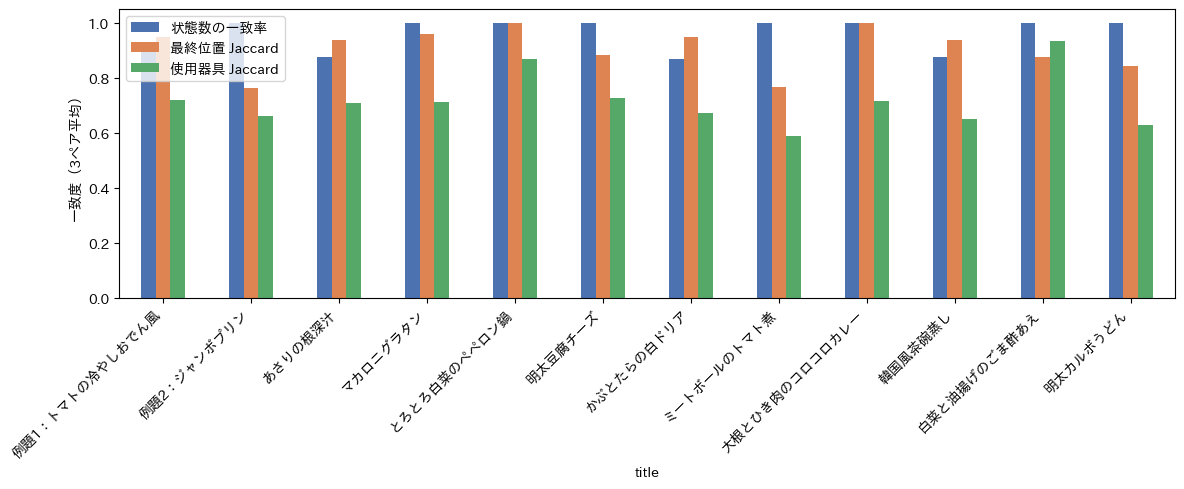

overall n_states match rate: 0.9619883040935673
overall container jaccard: 0.9003411306042884
overall utensil jaccard: 0.7121635106284229


In [17]:
# レシピごとの平均一致度（A-B, A-ad, B-ad の3ペア平均）
METRIC_LABELS = {
    "n_steps_match_rate": "状態数の一致率",
    "container_jaccard_mean": "最終位置 Jaccard",
    "utensil_jaccard_mean": "使用器具 Jaccard",
}
METRIC_COLORS = ["#4C72B0", "#DD8452", "#55A868"]

ax = per_recipe.set_index("title")[list(METRIC_LABELS)].rename(columns=METRIC_LABELS).plot.bar(
    figsize=(12, 5), color=METRIC_COLORS
)
ax.set_ylabel("一致度（3ペア平均）")
ax.set_ylim(0, 1.05)
ax.legend(title=None)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("overall n_states match rate:", pair_df["n_states_match"].mean())
print("overall container jaccard:", pair_df["container_jaccard"].mean())
print("overall utensil jaccard:", pair_df["utensil_jaccard"].mean())

## ペアごとの内訳（どの2人の組み合わせで一致度が低いか）

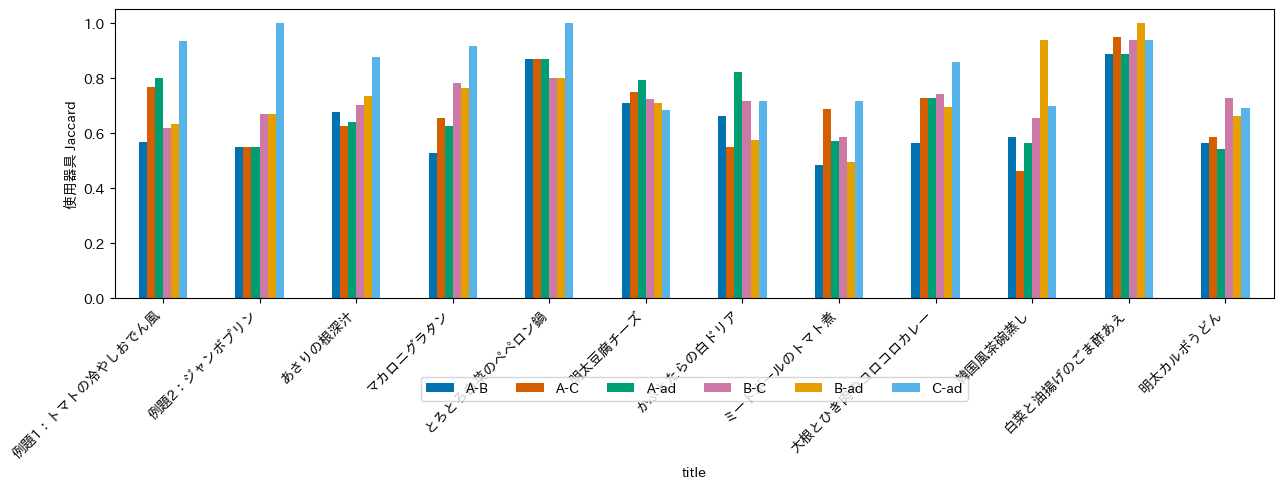

ペアごとの平均一致度:
      n_states_match  container_jaccard  utensil_jaccard
pair                                                    
A-B         0.947368           0.900585         0.628070
A-C         0.964912           0.932749         0.675021
A-ad        0.964912           0.896199         0.692105
B-C         0.947368           0.890351         0.716520
B-ad        0.982456           0.866959         0.713938
C-ad        0.964912           0.915205         0.847327


In [18]:
PAIR_ORDER = [f"{a1}-{a2}" for a1, a2 in itertools.combinations(ANNOTATORS, 2)]
PAIR_PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9"]
PAIR_COLORS = PAIR_PALETTE[:len(PAIR_ORDER)]

utensil_by_pair = per_recipe_pair.pivot(index="title", columns="pair", values="utensil_jaccard_mean")
utensil_by_pair = utensil_by_pair.loc[titles, PAIR_ORDER]

ax = utensil_by_pair.plot.bar(figsize=(13, 5), color=PAIR_COLORS)
ax.set_ylabel("使用器具 Jaccard")
ax.set_ylim(0, 1.05)
ax.legend(title=None, ncol=len(PAIR_ORDER), loc="upper center", bbox_to_anchor=(0.5, -0.25))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("ペアごとの平均一致度:")
print(pair_df.groupby("pair")[["n_states_match", "container_jaccard", "utensil_jaccard"]].mean())